In [1]:
import pandas as pd                             # pandas
import numpy as np                              # numpy
import matplotlib.pyplot as plt                 # matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # - 깨짐 방지
data1 = pd.read_csv('./kdrama.csv')             # 드라마 데이터 가져오기

In [2]:
# 컬럼명 한글로 변환
data1 = data1.rename(columns={
    "Name": "작품명","Aired Date": "방영 기간","Year of release": "공개 연도","Original Network": "원작 방송사","Aired On": "방영 요일"
    , "Number of Episodes": "총 에피 수","Duration": "회당 러닝타임","Content Rating": "시청 등급", "Rating": "평점","Synopsis": "줄거리"
    , "Genre": "장르","Tags": "태그","Director": "감독","Screenwriter": "각본","Cast": "출연진","Production companies": "제작사","Rank": "순위"
})
# 전체 장르명 한글로 변환해줄 딕셔너리
genre_kr = {
    'Romance': '로맨스','Drama': '드라마','Mystery': '미스터리','Comedy': '코미디','Thriller': '스릴러','Life': '일상','Action': '액션'
    ,'Melodrama': '멜로드라마','Historical': '사극','Fantasy': '판타지','Law': '법정','Crime': '범죄','Supernatural': '초자연','Psychological': '심리'
    ,'Political': '정치','Youth': '청춘','Medical': '의학','Family': '가족','Horror': '공포','Sci-Fi': 'SF','Friendship': '우정'
    ,'Business': '비즈니스','Sports': '스포츠','Military': '군대','Music': '음악','Adventure': '모험','Food': '음식','School': '학원','Sitcom': '시트콤'
}

def translate_genres(genre_str):
    if pd.isna(genre_str):
        return genre_str

    genres = [g.strip() for g in genre_str.split(',')]
    return ', '.join(genre_kr.get(g, g) for g in genres)

data1['장르'] = data1['장르'].apply(translate_genres)
data1['장르']



0              일상, 드라마, 가족
1      스릴러, 로맨스, 범죄, 멜로드라마
2          우정, 로맨스, 일상, 의학
3          우정, 로맨스, 일상, 의학
4          심리, 일상, 드라마, 가족
              ...         
245       사극, 로맨스, 의학, 판타지
246     사극, 로맨스, 멜로드라마, 정치
247       법정, 로맨스, 일상, 드라마
248      공포, 코미디, 로맨스, 판타지
249      액션, 스릴러, 미스터리, 범죄
Name: 장르, Length: 250, dtype: object

In [3]:
# 필요한 컬럼만 가져와서 DataFrame 새로 만들기
df1 = data1[['작품명', '장르', '공개 연도', '평점', '순위']].copy()
# 2010년 이전의 데이터는 데이터의 크기가 너무 작아 유의미한 의미를 가지지 못할것 같아 2010년 이전 데이터는 전부 제외
df1 = df1[df1['공개 연도'] >= 2010]                                
df1

,작품명,장르,공개 연도,평점,순위
0,Move to Heaven,"일상, 드라마, 가족",2021,9.2,#1
1,Flower of Evil,"스릴러, 로맨스, 범죄, 멜로드라마",2020,9.1,#2
2,Hospital Playlist,"우정, 로맨스, 일상, 의학",2020,9.1,#3
3,Hospital Playlist 2,"우정, 로맨스, 일상, 의학",2021,9.1,#4
4,My Mister,"심리, 일상, 드라마, 가족",2018,9.1,#5
...,...,...,...,...,...
245,Live Up to Your Name,"사극, 로맨스, 의학, 판타지",2017,8.3,#246
246,Queen for Seven Days,"사극, 로맨스, 멜로드라마, 정치",2017,8.3,#247
247,Memory,"법정, 로맨스, 일상, 드라마",2016,8.3,#248
248,A Korean Odyssey,"공포, 코미디, 로맨스, 판타지",2017,8.3,#249


# 가설1. OTT의 출시와 대중화는 장르선호도의 변화를 끼쳤을까? 
## 그룹핑 : OTT 출시전 :  2010–2015 / 넷플릭스 출시 : 2016–2018 / 넷플릭스 대중화 : 2019–2022

In [4]:
ott1 = df1[(df1['공개 연도'] >= 2010) & (df1['공개 연도'] <2016)]   #(10~15년도 데이터만 따로 추출)
ott2 = df1[(df1['공개 연도'] >= 2016) & (df1['공개 연도'] <2018)]   #(10~15년도 데이터만 따로 추출)
ott3 = df1[(df1['공개 연도'] >= 2019)]   #(10~15년도 데이터만 따로 추출)

In [5]:
# 1. 2016년까지의 데이터 문자열로 변환 개행 시켜주는 이스케이프 문자 제거
# 2. ','를 기준으로 분리 3. 공백 제거 4. 몇개인지 세주고
ott1_g = ott1['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ott2_g = ott2['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ott3_g = ott3['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()

In [6]:
# 년도별로 구분해둔 장르의 개수와 평균평점, 선호도를 저장해두는 데이터프레임 모음집 만드는 함수

# 매개변수 df = 시대구분 데이터프레임 / g = 장르의 이름 담아둔 리스트 / store = 데이터 프레임 담아둘 변수 이름 / name = 불러올 키값,구분명
def makeDf(df, g, store, name):
    dic = {}
    for i in g:
        dic[i] = df[df['장르'].str.contains(i)]['평점']

    store[name] = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {genre: (ratings.mean() 
                        * np.log(len(ratings) + 1)
                       ) 
                for genre, ratings in dic.items()}
    })

    store[name]['평균 평점'] = store[name]['평균 평점'].round(2)
    store[name]['선호도'] = store[name]['선호도'].round(2)

    store[name] = store[name].sort_values('선호도', ascending=False)

In [7]:
# 차트 그리는 함수  
def draw_chart(x,y,t):             # 매개변수 x => x축 / y => y축 / t => 차트 제목
    plt.figure(figsize=(12, 6))    # 차트 크기 키우고
    plt.xticks(rotation=45)        # x축의 이름 45도 기울이기 ==> 보기 편하게
    plt.grid(True, linestyle='--', alpha=0.6)     # 점선 넣기
    plt.title(t)
    plt.xlabel("장르")
    plt.ylabel("선호도")
    plt.text(0.65, 0.95,'선호도 = 평균 평점 × log(작품 수 + 1)',
        transform = plt.gca().transAxes,
        fontsize = 13,
        verticalalignment='top')
    plt.bar(x,y)                        # 차트에 x축 y축에 데이터 넣기
    #plt.show()                           # 차트 그리기

MovieWriter ffmpeg unavailable; using Pillow instead.


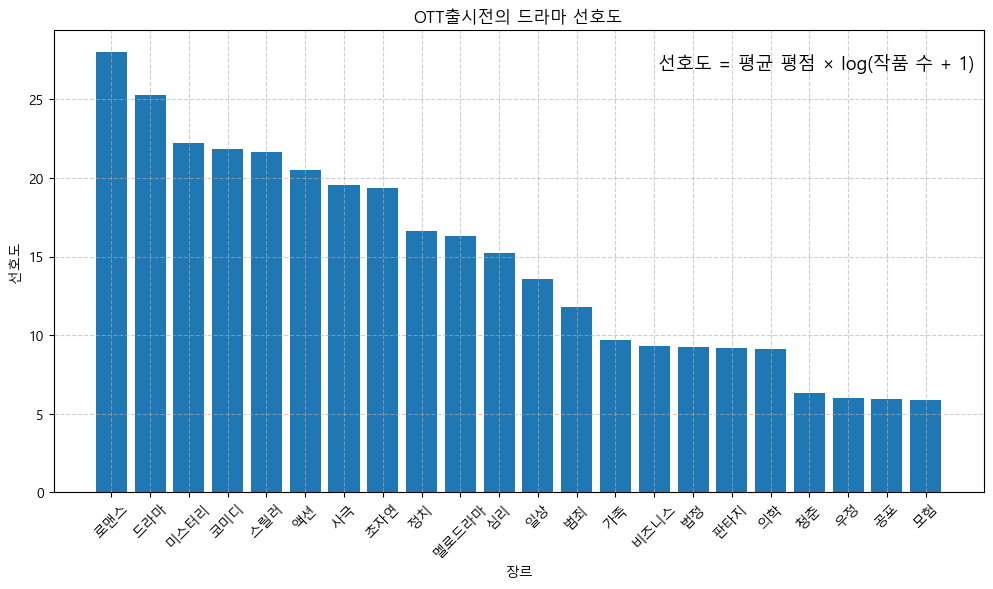

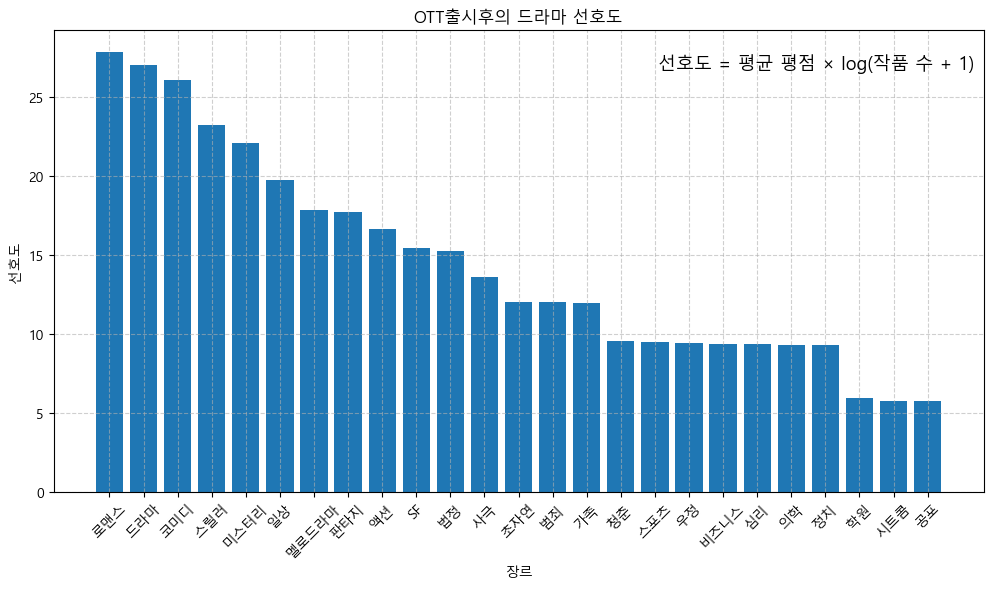

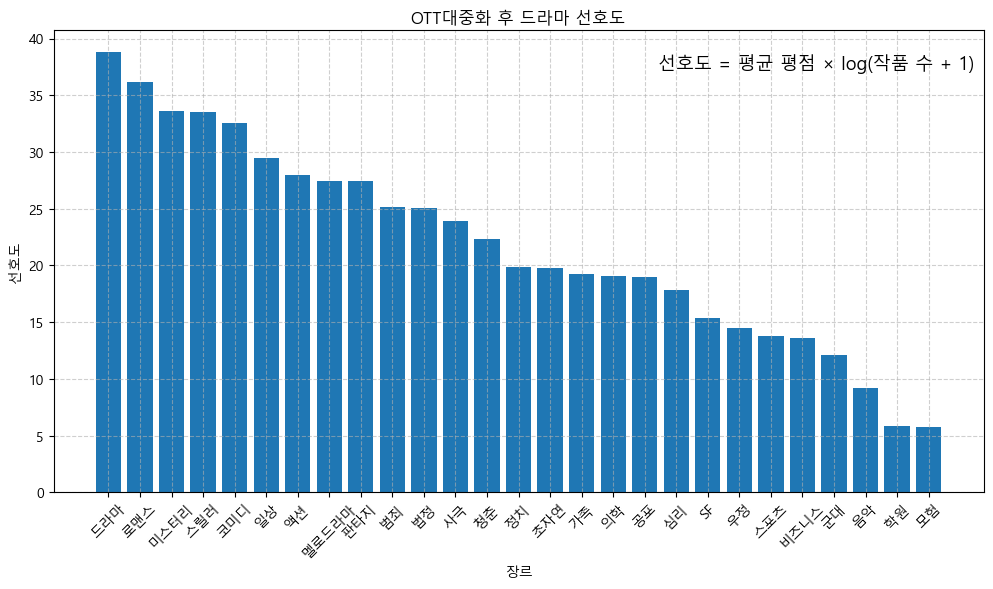

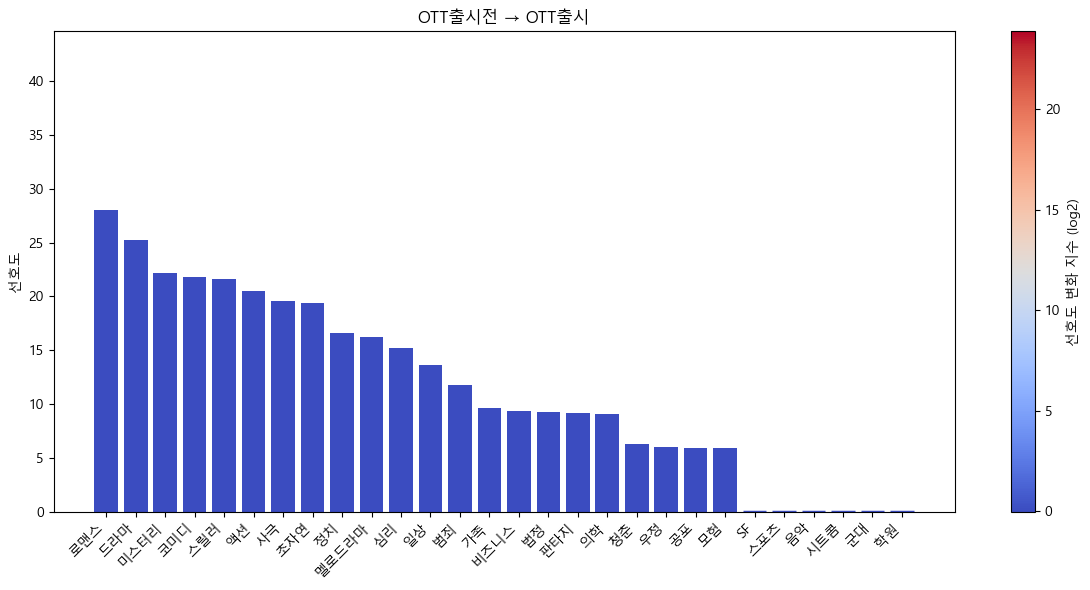

In [76]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import to_rgba

# 시대별 구분에 따른 데이터프레임 모읍집 생성
summary_store = {}

makeDf(ott1, ott1_g, summary_store, 'OTT출시전')
makeDf(ott2, ott2_g, summary_store, 'OTT출시')
makeDf(ott3, ott3_g, summary_store, 'OTT대중화')

ott1_summary = summary_store['OTT출시전']
ott2_summary = summary_store['OTT출시']
ott3_summary = summary_store['OTT대중화']

x1 = ott1_summary.index.tolist()                                  # x축 데이터
y1 = ott1_summary['선호도'].values                              # y축 데이터

draw_chart(x1,y1,'OTT출시전의 드라마 선호도')  

x2 = ott2_summary.index.tolist()                                  # x축 데이터
y2 = ott2_summary['선호도'].values                              # y축 데이터

draw_chart(x2,y2,'OTT출시후의 드라마 선호도')  

x3 = ott3_summary.index.tolist()                                  # x축 데이터
y3 = ott3_summary['선호도'].values                              # y축 데이터

draw_chart(x3,y3,'OTT대중화 후 드라마 선호도')  

scores = pd.DataFrame({
    "OTT출시전": ott1_summary["선호도"],
    "OTT출시": ott2_summary["선호도"],
    "OTT대중화": ott3_summary["선호도"],
}).fillna(0)

ranks = scores.rank(ascending=False, method="min")

periods = ["OTT출시전", "OTT출시", "OTT대중화"]
# periods = ["OTT출시전", "OTT출시"]
# periods = ["OTT출시", "OTT대중화"]
# periods = ["OTT출시전","OTT대중화"]

# 1) 기준 시기 정렬
base_period = periods[0]
scores_sorted = scores.sort_values(by=base_period, ascending=False)

genres = scores_sorted.index.tolist()
x = np.arange(len(genres))

# 2) 정렬된 값으로 애니메이션 값 준비
values = [scores_sorted[p].values for p in periods]

# 3) 색상 계산 (log2 변화) + 방어코드 + 0-start 주황 예외
log2_change = np.log2(
    (scores_sorted["OTT대중화"] + 1e-6) /
    (scores_sorted["OTT출시전"] + 1e-6)
)

vmin = float(np.nanmin(log2_change.values))
vmax = float(np.nanmax(log2_change.values))
if vmin == vmax:
    vmin -= 1e-3
    vmax += 1e-3

cmap = plt.cm.coolwarm
norm = plt.Normalize(vmin=vmin, vmax=vmax)
bar_colors = cmap(norm(log2_change.values))

zero_start_mask = (scores_sorted["OTT출시전"].values == 0)

# 4) plot
frames_per_stage = 60
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(x, values[0], color=bar_colors)

ax.set_ylim(0, scores_sorted[periods].values.max() * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("선호도")
title = ax.set_title(periods[0])

# 컬러바 (log2 기준)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("선호도 변화 지수 (log2)")

# zero_start_mask = (scores_sorted[periods[0]].values == 0)  # 기준시기(출시전) 0-start

bars = ax.bar(
    x, values[0],
    color=cmap(norm(np.zeros_like(values[0]))),  # 임시(어차피 update에서 바뀜)
    edgecolor=np.where(zero_start_mask, "#F28E2B", "none"),
    linewidth=np.where(zero_start_mask, 2.5, 0.0)
)

def update(frame):
    stage = frame // frames_per_stage
    t = (frame % frames_per_stage) / frames_per_stage
    t = t*t*(3 - 2*t)

    start = values[stage]
    end   = values[stage + 1]
    current = start + (end - start) * t

    # ✅ 프레임별 변화율로 색 계산 (0 나눗셈 방지)
    change = np.log2((current + 1e-6) / (start + 1e-6))
    colors = cmap(norm(change))

    for i, (bar, h, c) in enumerate(zip(bars, current, colors)):
        bar.set_height(h)
        bar.set_color(c)
        # 테두리는 고정이라 update에서 건드릴 필요 없음

    title.set_text(f"{periods[stage]} → {periods[stage+1]}")
    return bars

total_frames = frames_per_stage * (len(periods) - 1)

ani = FuncAnimation(fig, update, frames=total_frames, interval=40, repeat=True)

plt.tight_layout()
# ani.save("OTT.gif", dpi=150)
# plt.show()


Check


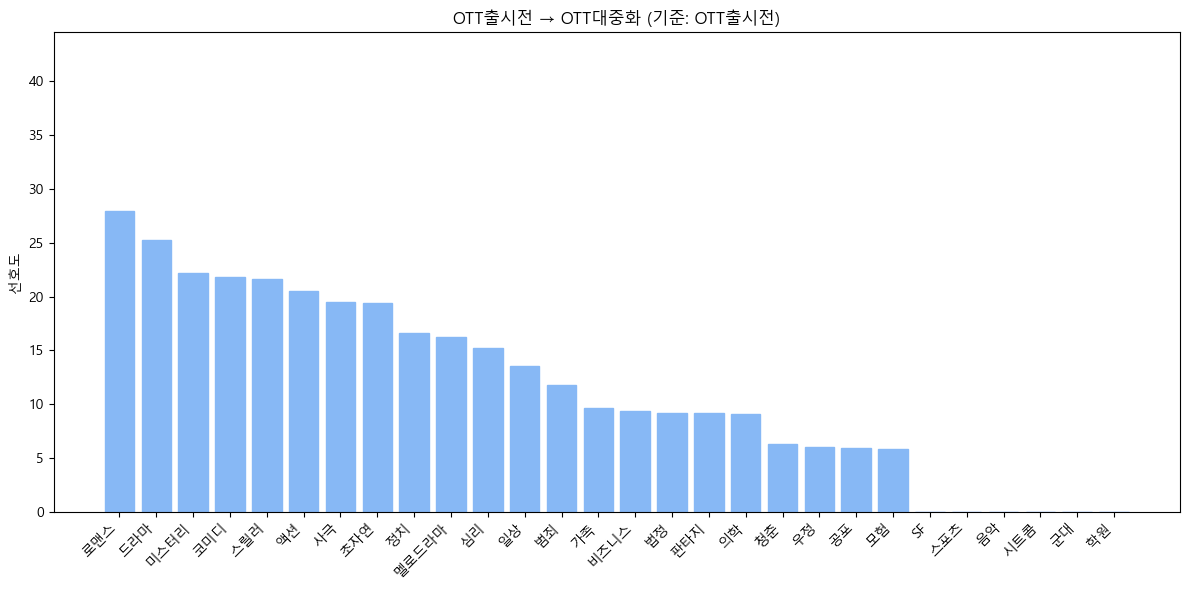

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import to_rgba

# =========================
# 0) 시기별 요약 DF 생성
# =========================
summary_store = {}

makeDf(ott1, ott1_g, summary_store, 'OTT출시전')
makeDf(ott2, ott2_g, summary_store, 'OTT출시')
makeDf(ott3, ott3_g, summary_store, 'OTT대중화')

ott1_summary = summary_store['OTT출시전']
ott2_summary = summary_store['OTT출시']
ott3_summary = summary_store['OTT대중화']

# =========================
# 1) 시기별 선호도 통합
# =========================
scores = pd.DataFrame({
    "OTT출시전": ott1_summary["선호도"],
    "OTT출시": ott2_summary["선호도"],
    "OTT대중화": ott3_summary["선호도"],
}).fillna(0)

# periods = ["OTT출시전", "OTT출시", "OTT대중화"]
# periods = ["OTT출시전", "OTT출시"]
# periods = ["OTT출시", "OTT대중화"]
periods = ["OTT출시전","OTT대중화"]

base_period = periods[0]

scores_sorted = scores.sort_values(by=base_period, ascending=False)

genres = scores_sorted.index.tolist()
x = np.arange(len(genres))

values = [scores_sorted[p].values.astype(float) for p in periods]

# =========================
# 2) 색상 규칙 설정
# =========================
eps = 1e-6
base = values[0].copy()

# 기준시기 0 → 주황 고정
fixed_orange_mask = (base == 0)
m = ~fixed_orange_mask

# 기준시기 대비 변화 크기(|log2|) 분포 수집
all_mag = []
for stage in range(len(periods) - 1):
    end = values[stage + 1]
    mag = np.abs(np.log2((end[m] + eps) / (base[m] + eps)))
    all_mag.append(mag)

all_mag = np.concatenate(all_mag)
all_mag = all_mag[np.isfinite(all_mag)]

# 대비 강화용 퍼센타일
lo, hi = np.percentile(all_mag, [10, 90])
vmin, vmax = float(lo), float(hi)
if vmin == vmax:
    vmin -= 0.1
    vmax += 0.1

def intensity(mag):
    return np.clip((mag - vmin) / (vmax - vmin), 0, 1)

# =========================
# 3) 푸른색 계열 (연 → 진)
# =========================
light_blue = np.array(to_rgba("#87b8f5"))  # 아주 연한 파랑
dark_blue  = np.array(to_rgba("#1F4E8C"))  # 진한 파랑
ORANGE = to_rgba("#61a7ff")

# =========================
# 4) 그래프 초기화
# =========================
frames_per_stage = 50
fig, ax = plt.subplots(figsize=(12, 6))

hold = 50  # 30프레임 추가 (40ms 기준 약 1.2초)
total_frames = frames_per_stage * (len(periods) - 1) + hold

init_colors = np.tile(light_blue, (len(genres), 1))
init_colors[fixed_orange_mask] = ORANGE

bars = ax.bar(x, values[0], color=init_colors)

ax.set_ylim(0, scores_sorted[periods].values.max() * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("선호도")
title = ax.set_title(f"{periods[0]} (기준: {periods[0]})")

# =========================
# 5) 애니메이션 업데이트
# =========================
def update(frame):
    last = frames_per_stage * (len(periods) - 1) - 1
    if frame > last:
        frame = last
    stage = frame // frames_per_stage
    t = (frame % frames_per_stage) / frames_per_stage
    t = t * t * (3 - 2 * t)  # easing

    start = values[stage]
    end   = values[stage + 1]
    current = start + (end - start) * t

    # 기준시기 대비 변화량 크기
    mag = np.zeros_like(current)
    mag[m] = np.abs(np.log2((current[m] + eps) / (base[m] + eps)))

    s = intensity(mag)

    # 푸른색 계열에서 진하기만 보간
    colors = (
        light_blue[None, :] * (1 - s[:, None]) +
        dark_blue[None, :]  * s[:, None]
    )

    # 주황 고정
    colors[fixed_orange_mask] = ORANGE

    for bar, h, c in zip(bars, current, colors):
        bar.set_height(h)
        bar.set_color(c)

    title.set_text(f"{periods[stage]} → {periods[stage+1]} (기준: {periods[0]})")
    return bars

ani = FuncAnimation(fig, update, frames=total_frames, interval=40, repeat=False)

plt.tight_layout()
# ani.save("OTT.gif", dpi=150, writer="pillow")
print("Check")

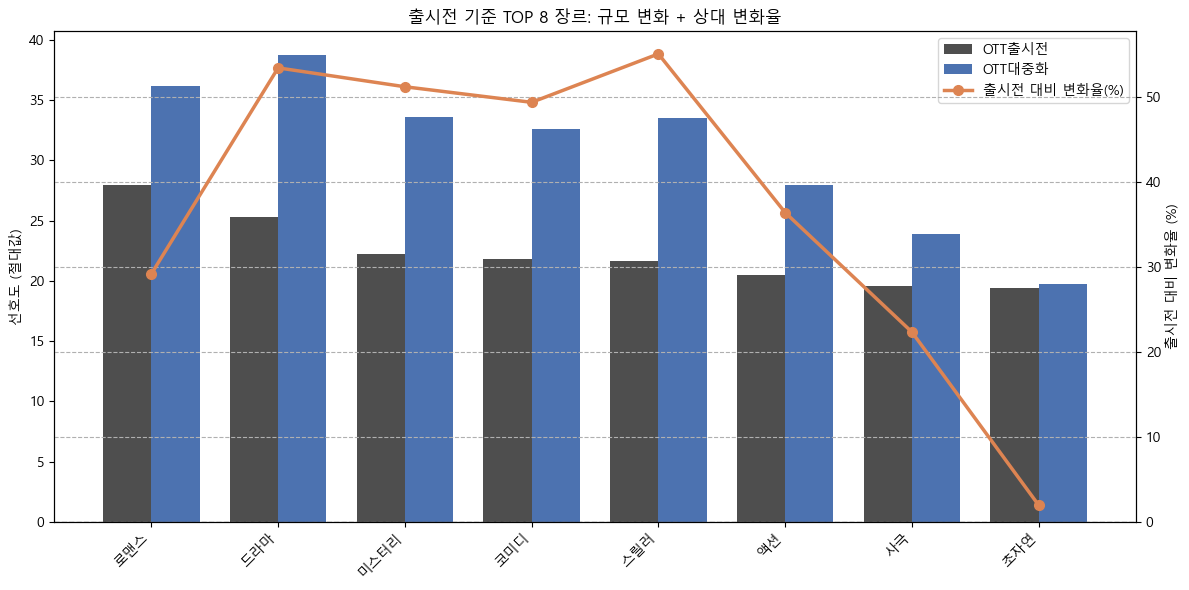

In [9]:
# 1) 데이터 준비 (절대값)
df = scores[["OTT출시전", "OTT대중화"]].copy()
df = df[(df["OTT출시전"] > 0) & (df["OTT대중화"] > 0)]

# 2) 출시전 기준 TOP 8
df_top8 = (
    df.sort_values("OTT출시전", ascending=False)
      .head(8)
)

# 3) 변화율(%)
df_top8["변화율(%)"] = (
    (df_top8["OTT대중화"] - df_top8["OTT출시전"])
    / df_top8["OTT출시전"]
) * 100

# 4) x축
genres = df_top8.index.tolist()
x = np.arange(len(genres))
w = 0.38

# 5) 그래프
fig, ax1 = plt.subplots(figsize=(12, 6))

# 🎨 (A) 출시전 막대 – 진한 회색
ax1.bar(
    x - w/2,
    df_top8["OTT출시전"],
    w,
    label="OTT출시전",
    color="#4E4E4E"
)

# 🎨 (B) 대중화 막대 – 파란색
ax1.bar(
    x + w/2,
    df_top8["OTT대중화"],
    w,
    label="OTT대중화",
    color="#4C72B0"
)
ax1.set_ylim(bottom=0)
ax1.set_ylabel("선호도 (절대값)")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")

# 🎨 (C) 변화율 선 – 빨간색 + 마커 강조
ax2 = ax1.twinx()
ax2.plot(
    x,
    df_top8["변화율(%)"],
    color="#DD8452",
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="출시전 대비 변화율(%)"
)
ax2.set_ylim(bottom=0)
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylabel("출시전 대비 변화율 (%)")

# 범례 통합
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("출시전 기준 TOP 8 장르: 규모 변화 + 상대 변화율")
plt.tight_layout()
plt.grid(linestyle='--')
plt.show()

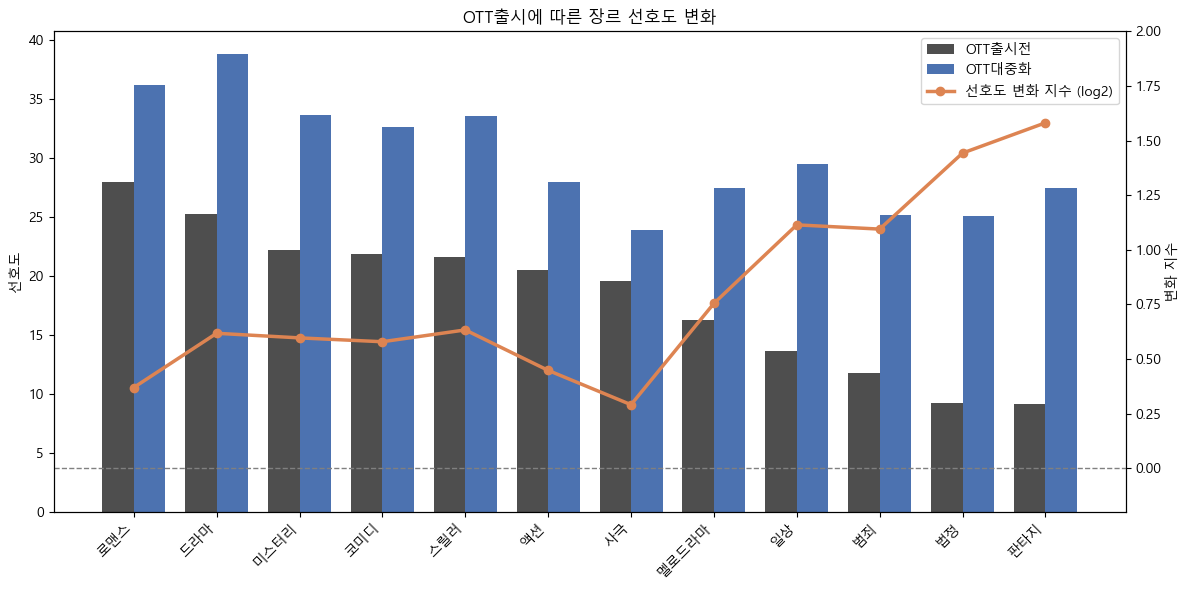

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 0) 데이터 준비
df = scores[["OTT출시전", "OTT대중화"]].copy()
df = df[(df["OTT출시전"] > 0) & (df["OTT대중화"] > 0)]

df_top10 = (
    df.sort_values("OTT대중화", ascending=False)
      .head(12)
      .copy()
)

# 2) 지표
df_top10["변화율(%)"] = (df_top10["OTT대중화"] - df_top10["OTT출시전"]) / df_top10["OTT출시전"] * 100
df_top10["log2_지수"] = np.log2(df_top10["OTT대중화"] / df_top10["OTT출시전"])

# ✅ 3) 핵심: 출시전(OTT출시전) 기준으로 내림차순 정렬
df_plot = df_top10.sort_values("OTT출시전", ascending=False).copy()

# ✅ 4) x축도 정렬된 df_plot에서 뽑기
genres = df_plot.index.to_list()
x = np.arange(len(genres))
w = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x - w/2, df_plot["OTT출시전"].to_numpy(), w, label="OTT출시전", color="#4E4E4E")
ax1.bar(x + w/2, df_plot["OTT대중화"].to_numpy(), w, label="OTT대중화", color="#4C72B0")

ax1.set_ylabel("선호도")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()
ax2.plot(x, df_plot["log2_지수"].to_numpy(),
         color="#DD8452", marker="o", linewidth=2.5, label="선호도 변화 지수 (log2)")
ax2.set_ylabel("변화 지수")
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylim(-0.2, 2)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("OTT출시에 따른 장르 선호도 변화")
plt.tight_layout()
# plt.savefig("OTT출시전과 대중화의 드라마 선호도 비교.png",dpi=300, bbox_inches='tight')
plt.show()

- 10개의 고른 기준 - OTT유행전에 선호도가 가장 높은 10개를 기준으로
- 고른 이유 - 가장 최신의 컬럼을 기준으로 하면 베이스(OTT 전 데이터)가 충분한 상태에서 변화했을거라 생각해서
- log2 이유 - 퍼센트로 보였을때 너무 100퍼센트가 넘어간 자료가 있으면 보기 불편할 수 있다고 생각해서
- 시간과 장소에 영향을 받지 않고 컨텐츠의 선택권이 사용자에게 넘어옴에 따라 스토리의 끊김 없이 오래 볼 수 있는 장르들의 선호도가 높아지고 있음
- 연속 시청에 유리하고 세계관, 감정선이 중요한 범죄, 판타지, 멜로, 일상드라마의 선호도가 눈에 띄게 증가함

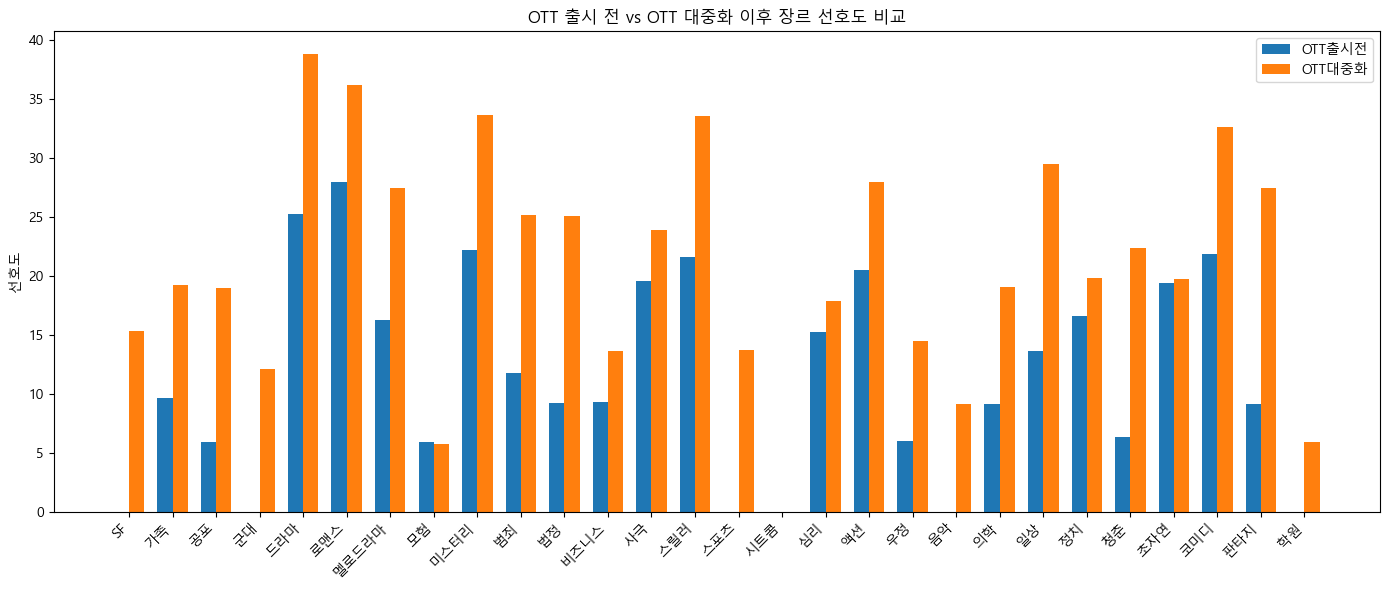

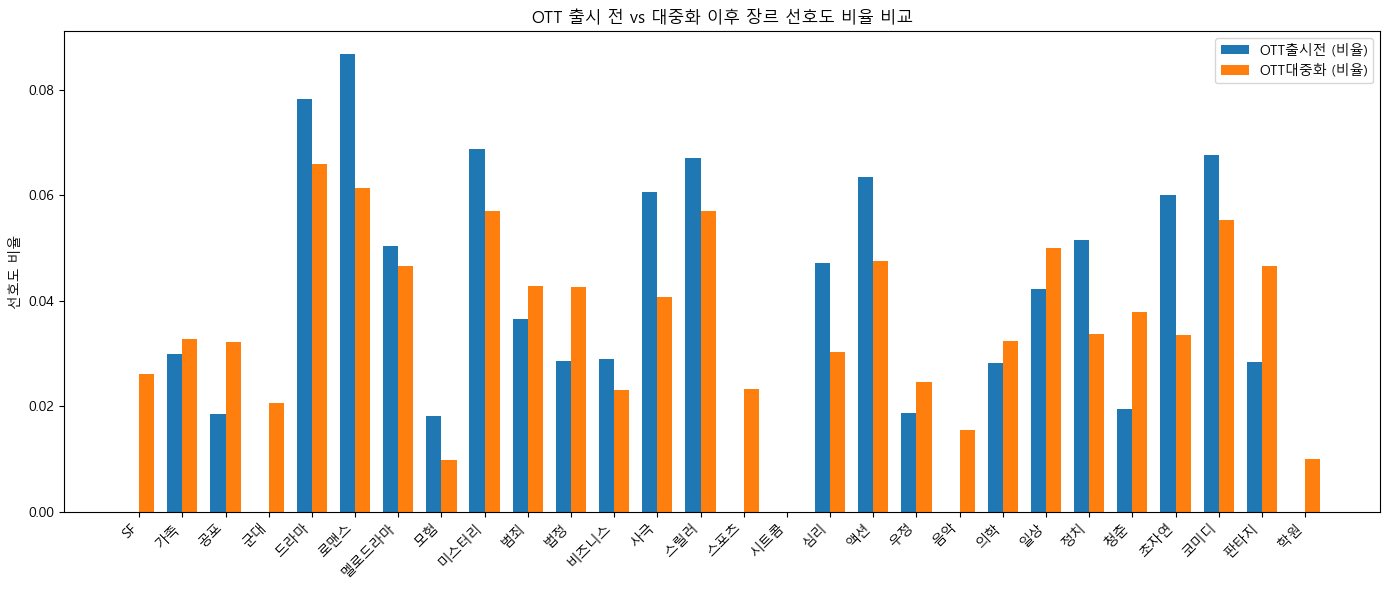

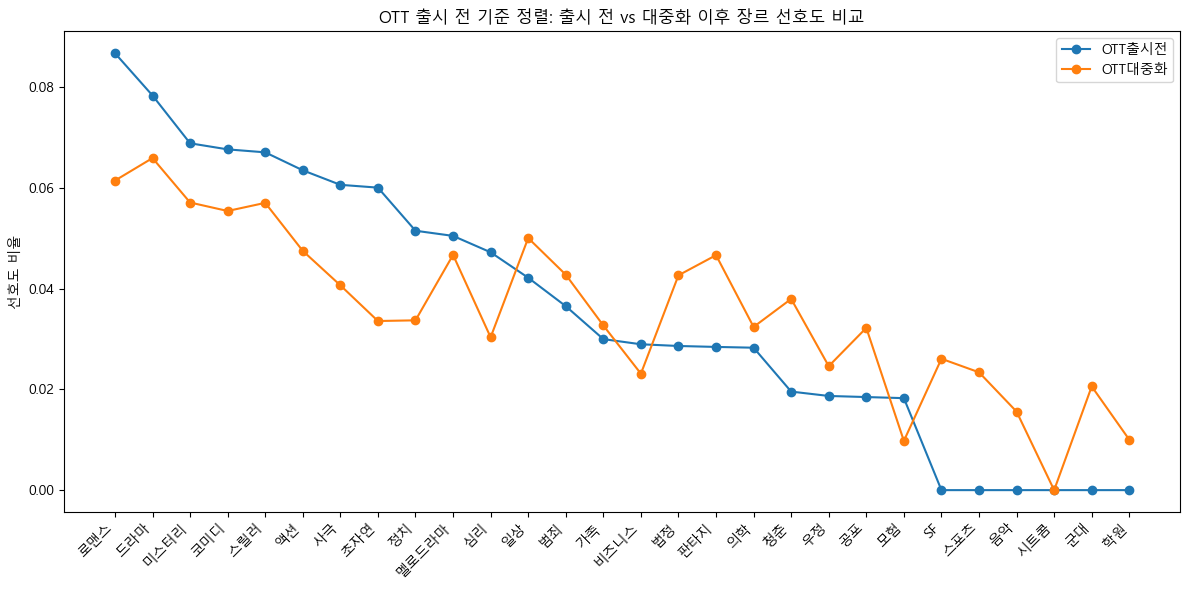

In [11]:

# 비교할 데이터만 추출
compare_df = scores[["OTT출시전", "OTT대중화"]]

# 장르 수
genres = compare_df.index.tolist()
x = np.arange(len(genres))
width = 0.35

plt.figure(figsize=(14, 6))

plt.bar(x - width/2, compare_df["OTT출시전"], width, label="OTT출시전")
plt.bar(x + width/2, compare_df["OTT대중화"], width, label="OTT대중화")

plt.xticks(x, genres, rotation=45, ha="right")
plt.ylabel("선호도")
plt.title("OTT 출시 전 vs OTT 대중화 이후 장르 선호도 비교")
plt.legend()
plt.tight_layout()
plt.show()

ratio_scores = scores.div(scores.sum(axis=0), axis=1)

compare_ratio = ratio_scores[["OTT출시전", "OTT대중화"]]

genres = compare_ratio.index.tolist()
x = np.arange(len(genres))
width = 0.35

plt.figure(figsize=(14, 6))

plt.bar(x - width/2, compare_ratio["OTT출시전"], width, label="OTT출시전 (비율)")
plt.bar(x + width/2, compare_ratio["OTT대중화"], width, label="OTT대중화 (비율)")

plt.xticks(x, genres, rotation=45, ha="right")
plt.ylabel("선호도 비율")
plt.title("OTT 출시 전 vs 대중화 이후 장르 선호도 비율 비교")
plt.legend()
plt.tight_layout()
plt.show()

import pandas as pd
import matplotlib.pyplot as plt


# 1) 시기별 비율 (각 열 합 = 1)
# ratio_scores = scores.div(scores.sum(axis=0), axis=1)

# 2) OTT출시전 기준으로 정렬
ratio_sorted = ratio_scores.sort_values(by="OTT출시전", ascending=False)

# 3) x축 (정렬된 장르)
genres = ratio_sorted.index.tolist()

# 4) 겹친 선 그래프
plt.figure(figsize=(12, 6))

plt.plot(
    genres,
    ratio_sorted["OTT출시전"],
    marker="o",
    label="OTT출시전"
)

plt.plot(
    genres,
    ratio_sorted["OTT대중화"],
    marker="o",
    label="OTT대중화"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("선호도 비율")
plt.title("OTT 출시 전 기준 정렬: 출시 전 vs 대중화 이후 장르 선호도 비교")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1) 필요한 열만
df = scores[["OTT출시전", "OTT대중화"]].copy()

# 2) 변화량 계산
df["변화량"] = df["OTT대중화"] - df["OTT출시전"]

# 3) 출시전 기준 정렬 (기준점 고정)
df = df.sort_values("OTT출시전", ascending=False)

df = df.head(10)

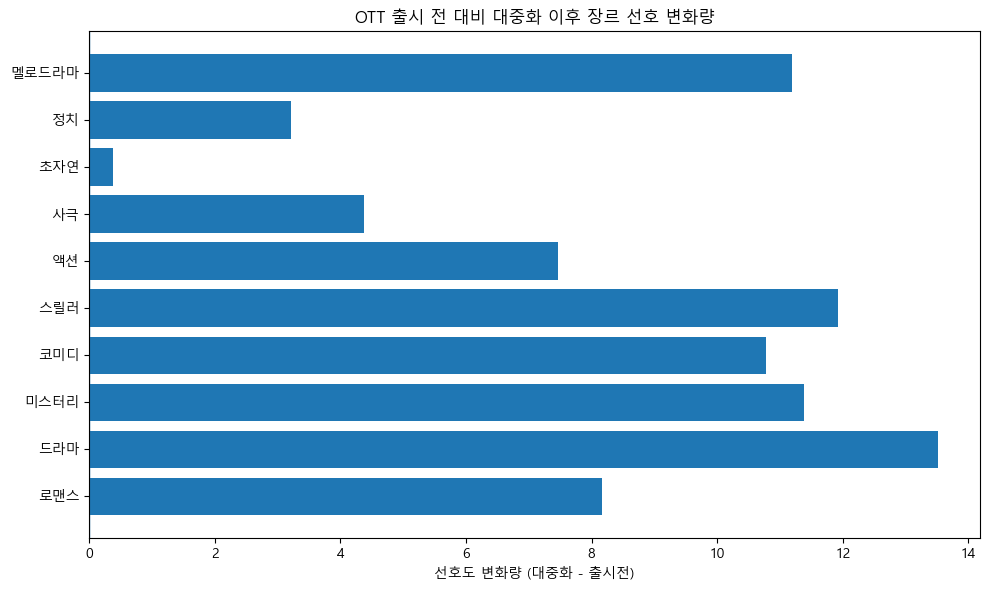

In [13]:
plt.figure(figsize=(10, max(6, len(df) * 0.35)))
plt.barh(df.index, df["변화량"])
plt.axvline(0, linewidth=1)

plt.title("OTT 출시 전 대비 대중화 이후 장르 선호 변화량")
plt.xlabel("선호도 변화량 (대중화 - 출시전)")
plt.tight_layout()
plt.show()

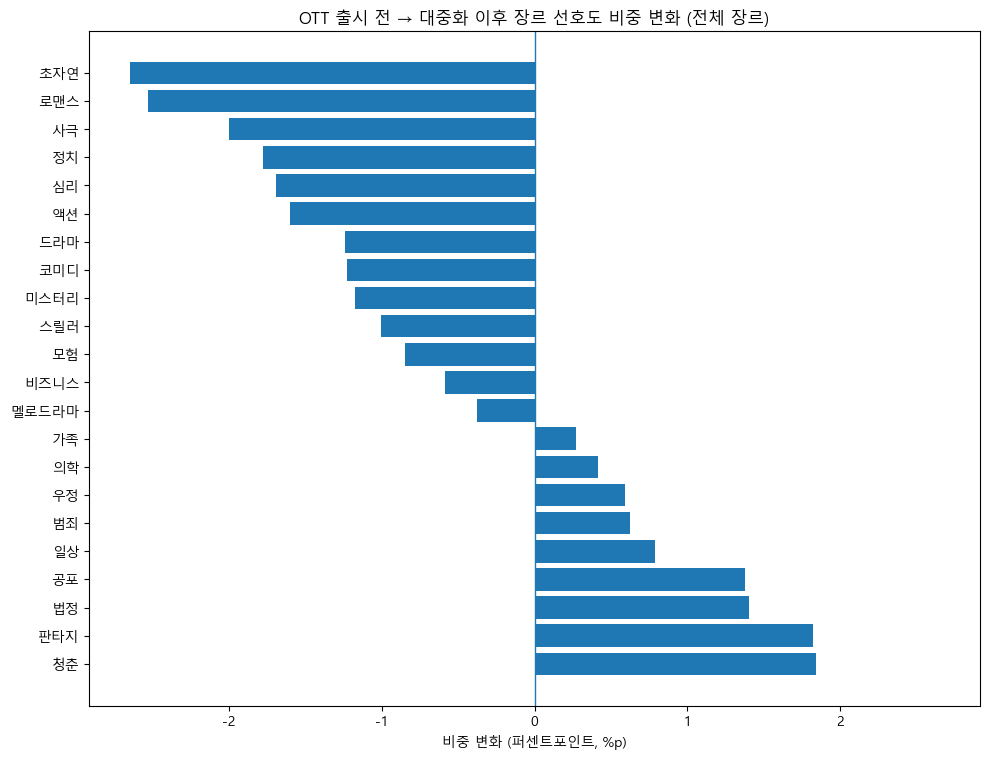

In [14]:
import matplotlib.pyplot as plt

# 1) 시기별 비율
ratio_scores = scores.div(scores.sum(axis=0), axis=1)

# 2) 두 시기 모두 0% 아닌 장르만 필터링
ratio_filtered = ratio_scores[
    (ratio_scores["OTT출시전"] > 0) &
    (ratio_scores["OTT대중화"] > 0)
].copy()

# 3) 변동량 계산 (대중화 - 출시전)
ratio_filtered["변동량"] = (
    ratio_filtered["OTT대중화"] - ratio_filtered["OTT출시전"]
)

# 4) 퍼센트포인트로 변환
ratio_filtered["변동량_pp"] = ratio_filtered["변동량"] * 100

# ✅ 5) 값 그대로 정렬 (증가 → 감소)
ratio_sorted = ratio_filtered.sort_values(
    by="변동량_pp",
    ascending=False
)

# 6) 가로 막대그래프
plt.figure(figsize=(10, max(6, len(ratio_sorted) * 0.35)))
plt.barh(ratio_sorted.index, ratio_sorted["변동량_pp"])
plt.axvline(0, linewidth=1)

plt.title("OTT 출시 전 → 대중화 이후 장르 선호도 비중 변화 (전체 장르)")
plt.xlabel("비중 변화 (퍼센트포인트, %p)")

# 7) 0이 정확히 중앙에 오도록 x축 대칭
max_abs = ratio_sorted["변동량_pp"].abs().max()
plt.xlim(-max_abs * 1.1, max_abs * 1.1)

plt.tight_layout()
plt.show()

- OTT 도입으로 시청자가 원하는 시간대에 원하는 장르를 원하는 만큼 볼 수 있게 바뀜
- 그렇기 때문에 지상파일때 회차가 길고 특정 시간대에만 하는 판타지와 법정, 일상, 드라마를 길게 끝까지 보는 사람이 적어짐
- OTT가 나오고 시청자는 꾸준히 오래 볼 수 있는 장르가 자연스럽게 떠오르게됨


In [15]:
delta = scores["OTT대중화"] - scores["OTT출시전"]
print(delta.sort_values().head(10))

모험     -0.14
시트콤     0.00
초자연     0.38
심리      2.62
정치      3.22
비즈니스    4.26
사극      4.37
학원      5.89
액션      7.46
로맨스     8.17
dtype: float64


In [16]:
genre_rank1 = {genre: i+1 for i, genre in enumerate(x1)}
genre_rank2 = {genre: i+1 for i, genre in enumerate(x2)}
genre_rank3 = {genre: i+1 for i, genre in enumerate(x3)}

common_genres = sorted(set(genre_rank1) & set(genre_rank2) & set(genre_rank3))

compare_df = pd.DataFrame({
    '장르': common_genres,
    'OTT 출시전': [genre_rank1[g] for g in common_genres],
    'OTT 출시후': [genre_rank2[g] for g in common_genres],
    'OTT 대중화': [genre_rank3[g] for g in common_genres],
})

compare_df = compare_df.sort_values('OTT 출시전').reset_index(drop=True)
compare_df

,장르,OTT 출시전,OTT 출시후,OTT 대중화
0,로맨스,1,1,2
1,드라마,2,2,1
2,미스터리,3,5,3
3,코미디,4,3,5
4,스릴러,5,4,4
5,액션,6,9,7
6,사극,7,12,12
7,초자연,8,13,15
8,정치,9,22,14
9,멜로드라마,10,7,8


In [17]:
for i in range(2003,2023):
    print(f"{i}년 : ",data1[(data1['공개 연도'] == i)]['공개 연도'].count())

2003년 :  1
2004년 :  0
2005년 :  0
2006년 :  1
2007년 :  1
2008년 :  0
2009년 :  1
2010년 :  1
2011년 :  4
2012년 :  7
2013년 :  11
2014년 :  7
2015년 :  9
2016년 :  13
2017년 :  27
2018년 :  24
2019년 :  37
2020년 :  35
2021년 :  39
2022년 :  32


In [18]:
genre_count = (
    data1[data1['공개 연도'] > 2005]['장르']
    .str.replace('\r', '', regex=False)   # 개행 문자 제거
    .str.split(',')                        # 쉼표 기준 분리
    .explode()                             # 행으로 펼치기
    .str.strip()                          # 앞뒤 공백 제거
    .value_counts()                       # 카운트
)

genre_count

장르
로맨스      135
드라마      129
미스터리      90
코미디       88
스릴러       86
일상        45
액션        45
멜로드라마     43
판타지       34
사극        33
법정        27
범죄        26
초자연       24
심리        19
정치        18
청춘        17
가족        15
의학        14
공포        11
SF        11
우정         9
비즈니스       9
스포츠        6
군대         4
음악         4
모험         3
학원         2
시트콤        1
음식         1
Name: count, dtype: int64

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df1 = data1  # 만약 현재 데이터프레임 이름이 data1이면 이 줄을 켜줘서 df1로 통일

# 장르 목록(딕셔너리 값들이 한글 장르명이니까 그걸 쓰는 게 안전)
g = list(genre_kr.values())

# 시기 분할(네 기준 유지)
ott1 = df1[(df1['공개 연도'] >= 2010) & (df1['공개 연도'] < 2016)]
ott2 = df1[(df1['공개 연도'] >= 2016) & (df1['공개 연도'] < 2018)]
ott3 = df1[(df1['공개 연도'] >= 2019)]

In [20]:
def makeDf(df, g, store, name):
    dic = {}
    for genre in g:
        ratings = df[df['장르'].str.contains(genre, na=False)]['평점']
        dic[genre] = ratings

    out = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {
            genre: (ratings.mean() * np.log(len(ratings) + 1))
            for genre, ratings in dic.items()
        }
    })

    out['평균 평점'] = out['평균 평점'].round(2)
    out['선호도'] = out['선호도'].round(2)

    store[name] = out.sort_values('선호도', ascending=False)

store = {}
makeDf(ott1, g, store, "2010-2015(전)")
makeDf(ott2, g, store, "2016-2017(중간)")
makeDf(ott3, g, store, "2019~(후)")

store["2010-2015(전)"].head(10), store["2019~(후)"].head(10)

(       갯수  평균 평점    선호도
 로맨스    26   8.49  27.98
 드라마    19   8.44  25.27
 미스터리   13   8.42  22.21
 코미디    12   8.51  21.82
 스릴러    12   8.43  21.63
 액션     10   8.54  20.48
 사극      9   8.49  19.55
 초자연     9   8.41  19.37
 정치      6   8.53  16.61
 멜로드라마   6   8.37  16.28,
        갯수  평균 평점    선호도
 드라마    92   8.56  38.78
 로맨스    68   8.54  36.15
 미스터리   51   8.50  33.59
 스릴러    50   8.53  33.55
 코미디    45   8.52  32.60
 일상     30   8.57  29.44
 액션     25   8.58  27.94
 멜로드라마  24   8.53  27.47
 판타지    24   8.52  27.44
 범죄     18   8.54  25.16)

In [21]:
pre = store["2010-2015(전)"][["갯수","평균 평점","선호도"]].copy()
post = store["2019~(후)"][["갯수","평균 평점","선호도"]].copy()

compare = pre.join(post, how="outer", lsuffix="_전", rsuffix="_후").fillna(0)

# 변화량/비율/로그비율(선호도 기준)
compare["선호도_변화량"] = compare["선호도_후"] - compare["선호도_전"]
compare["선호도_비율"] = (compare["선호도_후"] + 1e-9) / (compare["선호도_전"] + 1e-9)
compare["선호도_log2비율"] = np.log2(compare["선호도_비율"])

# 보기: 변화가 큰 TOP 12
topN = 12
top_change = compare.sort_values("선호도_변화량", ascending=False).head(topN)
top_drop   = compare.sort_values("선호도_변화량", ascending=True).head(topN)

top_change

,갯수_전,평균 평점_전,선호도_전,갯수_후,평균 평점_후,선호도_후,선호도_변화량,선호도_비율,선호도_log2비율
판타지,2,8.35,9.17,24,8.52,27.44,18.27,2.992366e+00,1.581287
청춘,1,9.10,6.31,13,8.46,22.33,16.02,3.538827e+00,1.823271
법정,2,8.40,9.23,18,8.52,25.09,15.86,2.718310e+00,1.442710
일상,4,8.45,13.60,30,8.57,29.44,15.84,2.164706e+00,1.114171
SF,0,0.00,0.00,5,8.56,15.34,15.34,1.534000e+10,33.836579
스포츠,0,0.00,0.00,4,8.55,13.76,13.76,1.376000e+10,33.679761
드라마,19,8.44,25.27,92,8.56,38.78,13.51,1.534626e+00,0.617887
범죄,3,8.50,11.78,18,8.54,25.16,13.38,2.135823e+00,1.094792
공포,1,8.60,5.96,8,8.62,18.95,12.99,3.179530e+00,1.668814
군대,0,0.00,0.00,3,8.73,12.11,12.11,1.211000e+10,33.495480


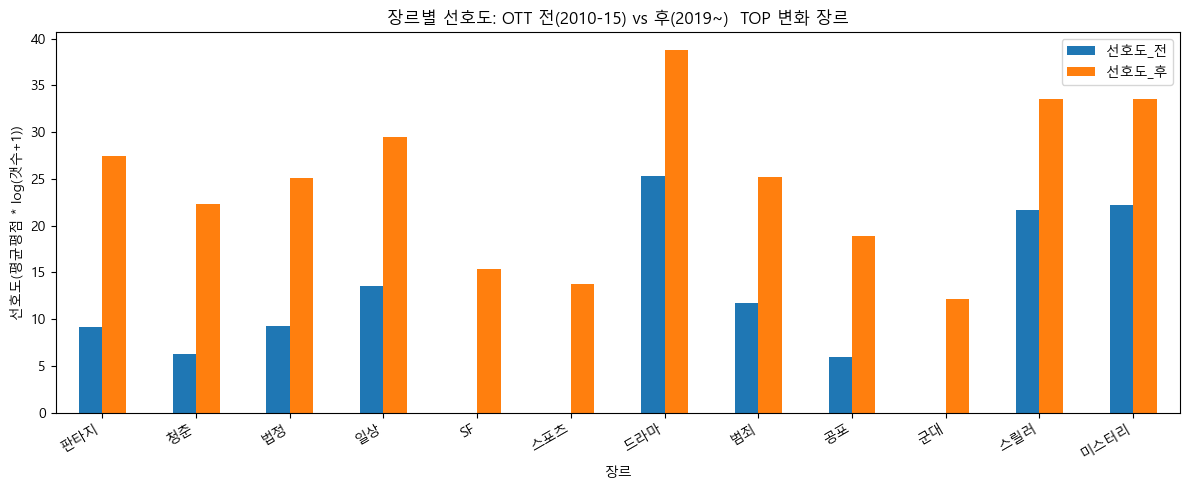

In [22]:
ax = top_change[["선호도_전","선호도_후"]].plot(kind="bar", figsize=(12,5))
ax.set_title("장르별 선호도: OTT 전(2010-15) vs 후(2019~)  TOP 변화 장르")
ax.set_xlabel("장르")
ax.set_ylabel("선호도(평균평점 * log(갯수+1))")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

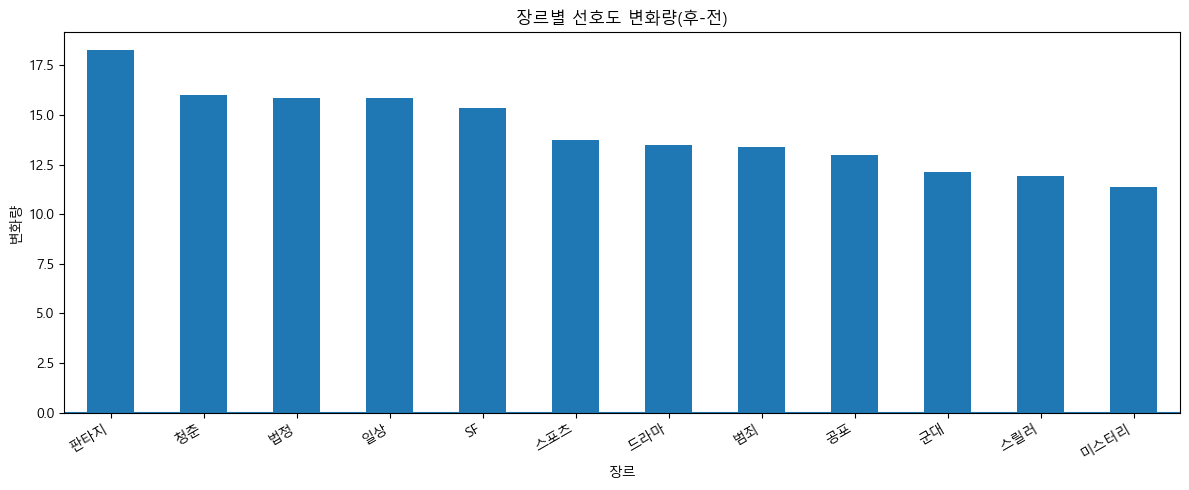

In [23]:
ax = top_change["선호도_변화량"].plot(kind="bar", figsize=(12,5))
ax.axhline(0)
ax.set_title("장르별 선호도 변화량(후-전)")
ax.set_xlabel("장르")
ax.set_ylabel("변화량")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

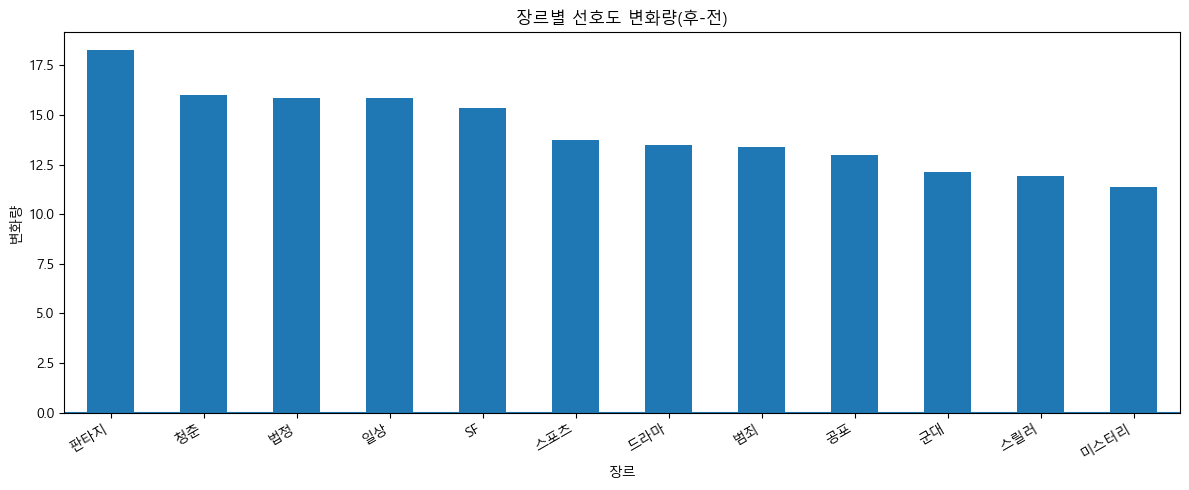

In [24]:
ax = top_change["선호도_변화량"].plot(kind="bar", figsize=(12,5))
ax.axhline(0)
ax.set_title("장르별 선호도 변화량(후-전)")
ax.set_xlabel("장르")
ax.set_ylabel("변화량")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

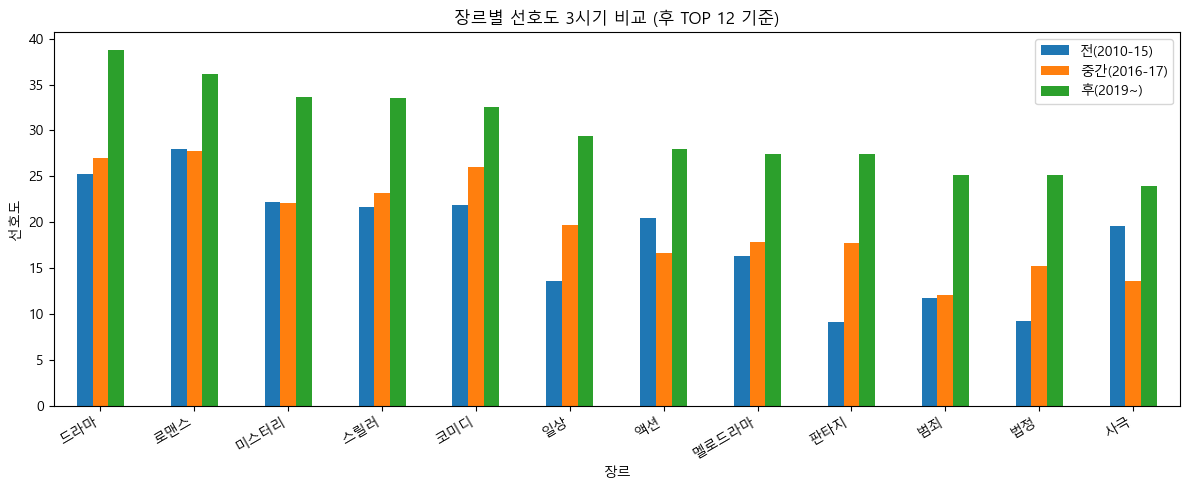

In [25]:
# 후 기준 TOP 12 장르를 뽑아서 3시기 비교
top_genres = store["2019~(후)"].head(12).index

three = pd.DataFrame({
    "전(2010-15)": store["2010-2015(전)"].reindex(top_genres)["선호도"],
    "중간(2016-17)": store["2016-2017(중간)"].reindex(top_genres)["선호도"],
    "후(2019~)": store["2019~(후)"].reindex(top_genres)["선호도"],
}).fillna(0)

ax = three.plot(kind="bar", figsize=(12,5))
ax.set_title("장르별 선호도 3시기 비교 (후 TOP 12 기준)")
ax.set_xlabel("장르")
ax.set_ylabel("선호도")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# //////////////////////////////////////////////////////////////////////////////////////////////////////

In [96]:
ur1 = df1[df1['공개 연도'] <= 2016]
ur2 = df1[(df1['공개 연도'] > 2016) & (df1['공개 연도'] <= 2020)]
ur3 = df1[df1['공개 연도'] > 2020]

In [97]:
# 1. 2016년까지의 데이터 문자열로 변환 개행 시켜주는 이스케이프 문자 제거
# 2. ','를 기준으로 분리 
# 3. 공백 제거
# 4. 몇개인지 세주고
# 5. 그중에 indcx를 뽑아서 리스트화
ur1_g = ur1['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur2_g = ur2['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()
ur3_g = ur3['장르'].str.replace('\r','',regex=False).str.split(',').explode().str.strip().value_counts().index.tolist()

In [98]:
def makeDf(df, g, store, name):
    dic = {}
    for i in g:
        dic[i] = df[df['장르'].str.contains(i)]['평점']

    store[name] = pd.DataFrame({
        '갯수': {genre: len(ratings) for genre, ratings in dic.items()},
        '평균 평점': {genre: ratings.mean() for genre, ratings in dic.items()},
        '선호도': {genre: (ratings.mean() * np.log(len(ratings) + 1)) for genre, ratings in dic.items()}
    })

    store[name]['평균 평점'] = store[name]['평균 평점'].round(2)
    store[name]['선호도'] = store[name]['선호도'].round(2)

    store[name] = store[name].sort_values('선호도', ascending=False)

MovieWriter ffmpeg unavailable; using Pillow instead.


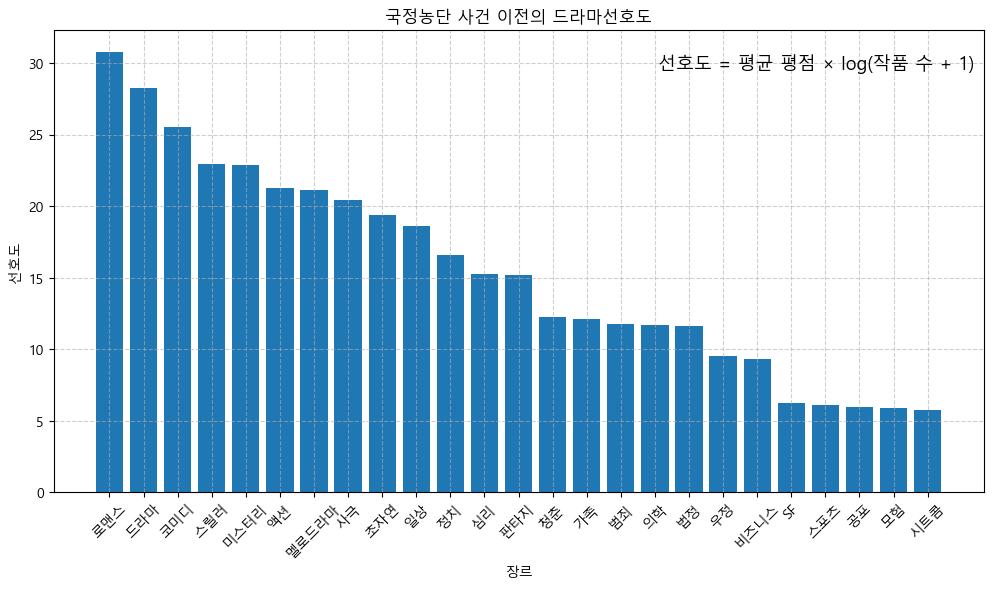

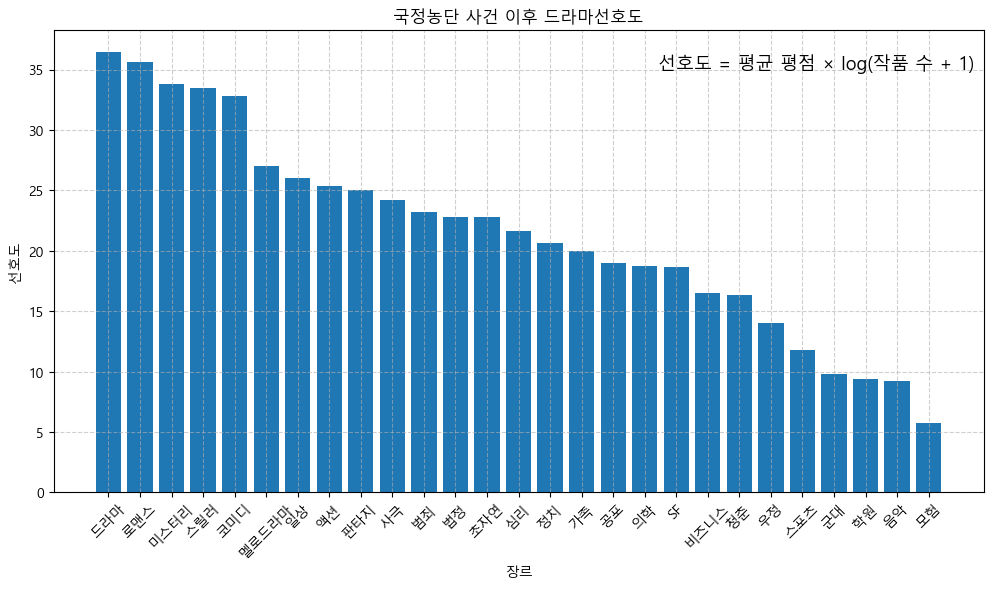

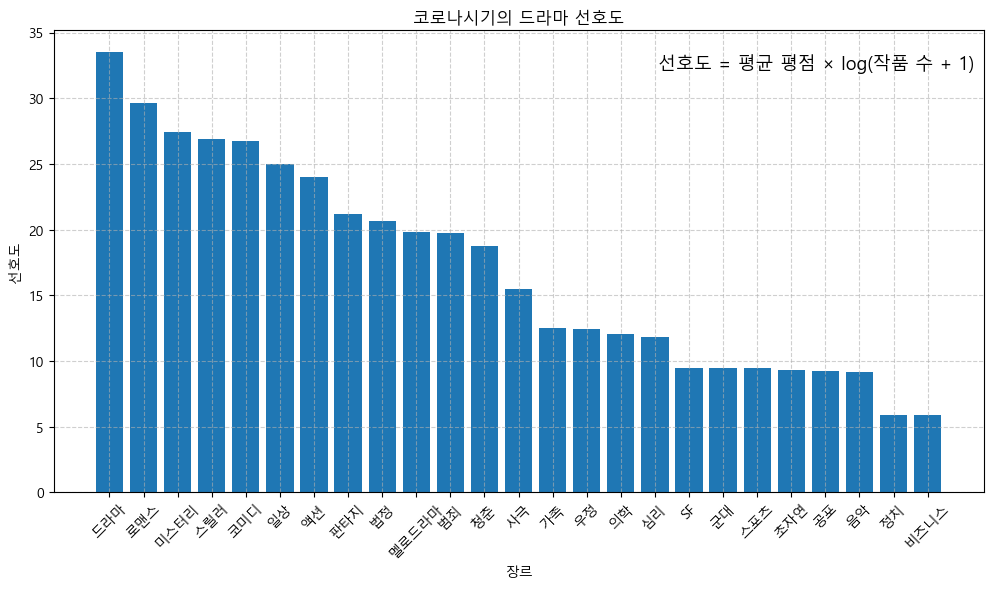

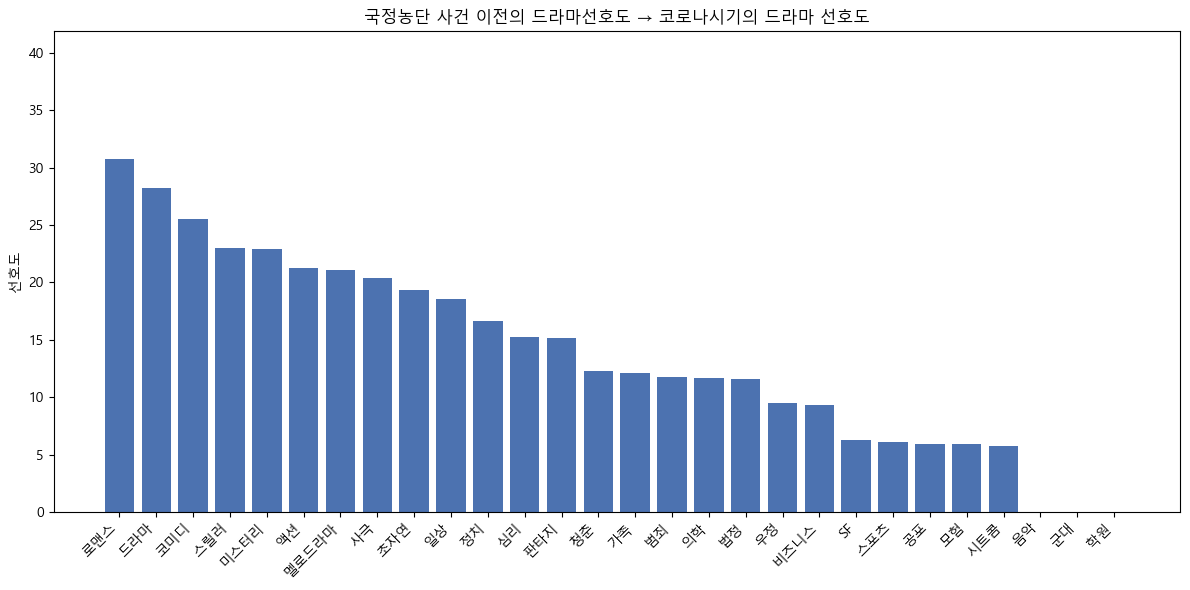

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

summary_store = {}

makeDf(ur1, ur1_g, summary_store, '농단전')
makeDf(ur2, ur2_g, summary_store, '농단후')
makeDf(ur3, ur3_g, summary_store, '코로나')

ur1_summary = summary_store['농단전']
ur2_summary = summary_store['농단후']
ur3_summary = summary_store['코로나']

x1 = ur1_summary.index.to_list()
y1 = ur1_summary['선호도'].values
draw_chart(x1,y1,'국정농단 사건 이전의 드라마선호도')

x2 = ur2_summary.index.to_list()
y2 = ur2_summary['선호도'].values
draw_chart(x2,y2,'국정농단 사건 이후 드라마선호도')

x3 = ur3_summary.index.to_list()
y3 = ur3_summary['선호도'].values
draw_chart(x3,y3,'코로나시기의 드라마 선호도')

scores = pd.DataFrame({
    "국정농단 사건 이전의 드라마선호도": ur1_summary["선호도"],
    "국정농단 사건 이후 드라마선호도": ur2_summary["선호도"],
    "코로나시기의 드라마 선호도": ur3_summary["선호도"],
}).fillna(0)

ranks = scores.rank(ascending=False, method="min")

# periods = ["국정농단 사건 이전의 드라마선호도", "국정농단 사건 이후 드라마선호도", "코로나시기의 드라마 선호도"]
# periods = ["국정농단 사건 이전의 드라마선호도", "국정농단 사건 이후 드라마선호도"]
# periods = ["국정농단 사건 이후 드라마선호도", "코로나시기의 드라마 선호도"]
periods = ["국정농단 사건 이전의 드라마선호도", "코로나시기의 드라마 선호도"]

# 🔥 기준 시기(첫 번째)
base_period = periods[0]

# 🔥 여기서 정렬
scores_sorted = scores.sort_values(by=base_period, ascending=False)

genres = scores_sorted.index.tolist()
x = np.arange(len(genres))


# 각 시점 값
values = [scores_sorted[p].values for p in periods]

frames_per_stage = 60  # ← 이 숫자 키울수록 더 부드러움

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(x, values[0], color="#4C72B0")

ax.set_ylim(0, scores.values.max() * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("선호도")
title = ax.set_title(periods[0])

def update(frame):
    stage = frame // frames_per_stage          # 0 or 1
    t = (frame % frames_per_stage) / frames_per_stage
    t = t*t*(3 - 2*t)

    start = values[stage]
    end   = values[stage + 1]

    current = start + (end - start) * t

    for bar, h in zip(bars, current):
        bar.set_height(h)

    title.set_text(f"{periods[stage]} → {periods[stage+1]}")
    return bars

total_frames = frames_per_stage * (len(periods) - 1)

ani = FuncAnimation(
    fig,
    update,
    frames=total_frames,
    interval=40,
    repeat=True
)

plt.tight_layout()
ani.save("사회불안.gif", dpi=150)

Check


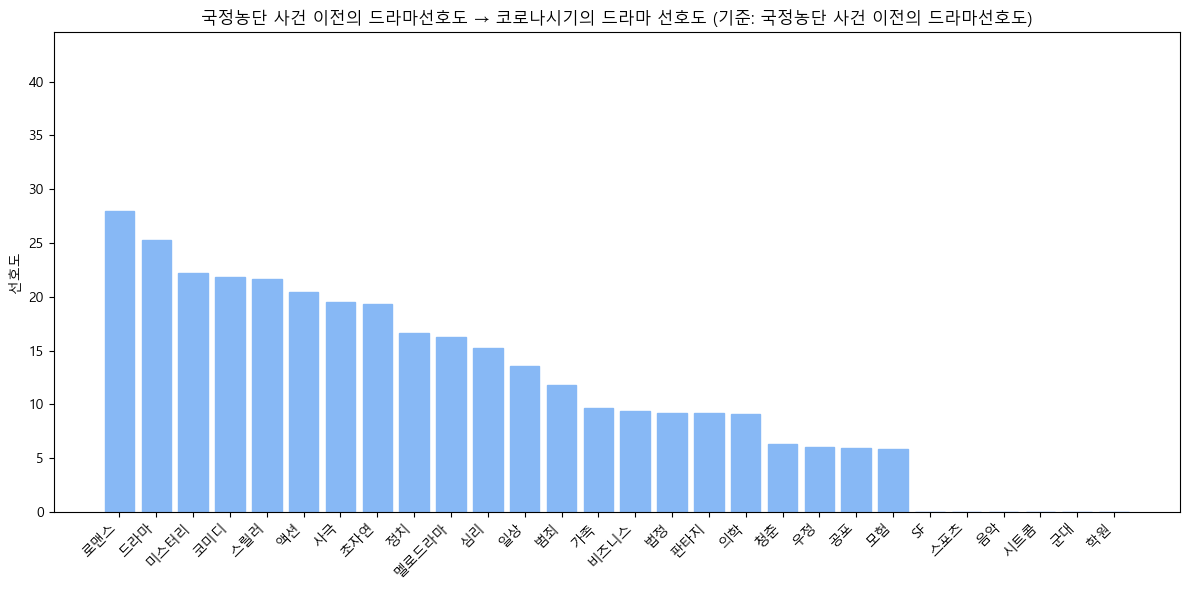

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import to_rgba

# =========================
# 0) 시기별 요약 DF 생성
# =========================
summary_store = {}

makeDf(ott1, ott1_g, summary_store, '국정농단 사건 이전의 드라마선호도')
makeDf(ott2, ott2_g, summary_store, '국정농단 사건 이후 드라마선호도')
makeDf(ott3, ott3_g, summary_store, '코로나시기의 드라마 선호도')

ott1_summary = summary_store['국정농단 사건 이전의 드라마선호도']
ott2_summary = summary_store['국정농단 사건 이후 드라마선호도']
ott3_summary = summary_store['코로나시기의 드라마 선호도']

# =========================
# 1) 시기별 선호도 통합
# =========================
scores = pd.DataFrame({
    "국정농단 사건 이전의 드라마선호도": ott1_summary["선호도"],
    "국정농단 사건 이후 드라마선호도": ott2_summary["선호도"],
    "코로나시기의 드라마 선호도": ott3_summary["선호도"],
}).fillna(0)

# periods = ["국정농단 사건 이전의 드라마선호도", "국정농단 사건 이후 드라마선호도", "코로나시기의 드라마 선호도"]
# periods = ["국정농단 사건 이전의 드라마선호도", "국정농단 사건 이후 드라마선호도"]
# periods = ["국정농단 사건 이후 드라마선호도", "코로나시기의 드라마 선호도"]
periods = ["국정농단 사건 이전의 드라마선호도","코로나시기의 드라마 선호도"]

base_period = periods[0]

scores_sorted = scores.sort_values(by=base_period, ascending=False)

genres = scores_sorted.index.tolist()
x = np.arange(len(genres))

values = [scores_sorted[p].values.astype(float) for p in periods]

# =========================
# 2) 색상 규칙 설정
# =========================
eps = 1e-6
base = values[0].copy()

# 기준시기 0 → 주황 고정
fixed_orange_mask = (base == 0)
m = ~fixed_orange_mask

# 기준시기 대비 변화 크기(|log2|) 분포 수집
all_mag = []
for stage in range(len(periods) - 1):
    end = values[stage + 1]
    mag = np.abs(np.log2((end[m] + eps) / (base[m] + eps)))
    all_mag.append(mag)

all_mag = np.concatenate(all_mag)
all_mag = all_mag[np.isfinite(all_mag)]

# 대비 강화용 퍼센타일
lo, hi = np.percentile(all_mag, [10, 90])
vmin, vmax = float(lo), float(hi)
if vmin == vmax:
    vmin -= 0.1
    vmax += 0.1

def intensity(mag):
    return np.clip((mag - vmin) / (vmax - vmin), 0, 1)

# =========================
# 3) 푸른색 계열 (연 → 진)
# =========================
light_blue = np.array(to_rgba("#87b8f5"))  # 아주 연한 파랑
dark_blue  = np.array(to_rgba("#1F4E8C"))  # 진한 파랑
ORANGE = to_rgba("#61a7ff")

# =========================
# 4) 그래프 초기화
# =========================
frames_per_stage = 50
fig, ax = plt.subplots(figsize=(12, 6))

hold = 50  # 30프레임 추가 (40ms 기준 약 1.2초)
total_frames = frames_per_stage * (len(periods) - 1) + hold

init_colors = np.tile(light_blue, (len(genres), 1))
init_colors[fixed_orange_mask] = ORANGE

bars = ax.bar(x, values[0], color=init_colors)

ax.set_ylim(0, scores_sorted[periods].values.max() * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("선호도")
title = ax.set_title(f"{periods[0]} (기준: {periods[0]})")

# =========================
# 5) 애니메이션 업데이트
# =========================
def update(frame):
    last = frames_per_stage * (len(periods) - 1) - 1
    if frame > last:
        frame = last
    stage = frame // frames_per_stage
    t = (frame % frames_per_stage) / frames_per_stage
    t = t * t * (3 - 2 * t)  # easing

    start = values[stage]
    end   = values[stage + 1]
    current = start + (end - start) * t

    # 기준시기 대비 변화량 크기
    mag = np.zeros_like(current)
    mag[m] = np.abs(np.log2((current[m] + eps) / (base[m] + eps)))

    s = intensity(mag)

    # 푸른색 계열에서 진하기만 보간
    colors = (
        light_blue[None, :] * (1 - s[:, None]) +
        dark_blue[None, :]  * s[:, None]
    )

    # 주황 고정
    colors[fixed_orange_mask] = ORANGE

    for bar, h, c in zip(bars, current, colors):
        bar.set_height(h)
        bar.set_color(c)

    title.set_text(f"{periods[stage]} → {periods[stage+1]} (기준: {periods[0]})")
    return bars

ani = FuncAnimation(fig, update, frames=total_frames, interval=40, repeat=False)

plt.tight_layout()
# ani.save("사회불안.gif", dpi=150, writer="pillow")
print("Check")

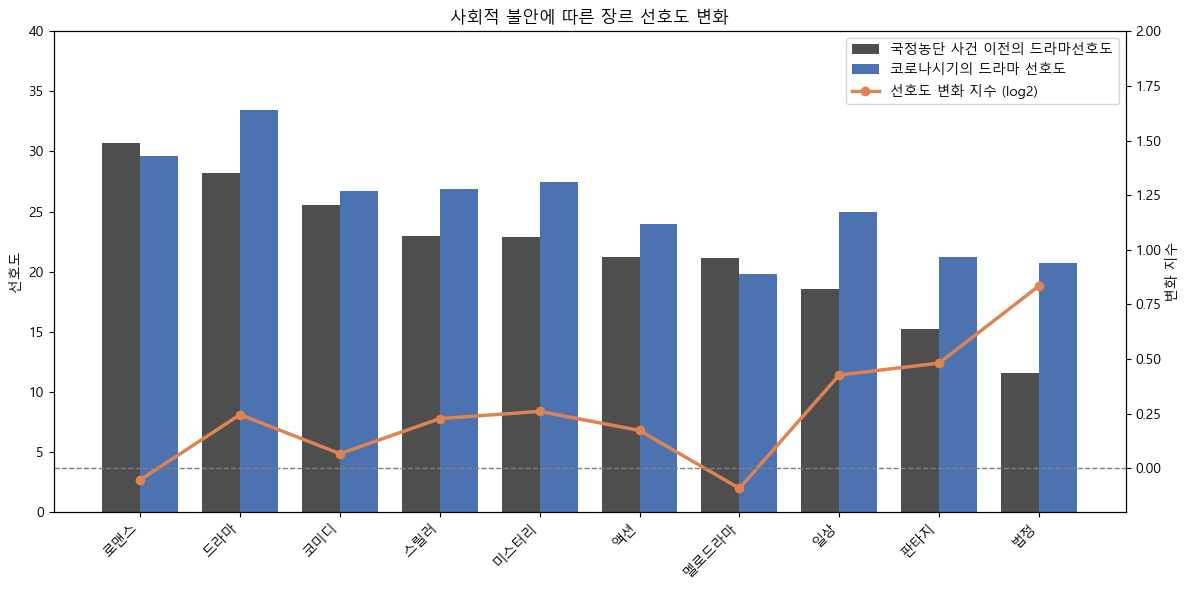

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 0) 데이터 준비
df = scores[["국정농단 사건 이전의 드라마선호도", "코로나시기의 드라마 선호도"]].copy()
df = df[(df["국정농단 사건 이전의 드라마선호도"] > 0) & (df["코로나시기의 드라마 선호도"] > 0)]

# 1) (너가 원하면) 전체 TOP10 뽑기: 두 시기 중 최대값 기준
df_top10 = (
    df.sort_values("코로나시기의 드라마 선호도", ascending=False)
      .head(10)
      .copy()
)

# 2) 지표
df_top10["변화율(%)"] = (df_top10["코로나시기의 드라마 선호도"] - df_top10["국정농단 사건 이전의 드라마선호도"]) / df_top10["국정농단 사건 이전의 드라마선호도"] * 100
df_top10["log2_지수"] = np.log2(df_top10["코로나시기의 드라마 선호도"] / df_top10["국정농단 사건 이전의 드라마선호도"])

# ✅ 3) 핵심: 출시전(OTT출시전) 기준으로 내림차순 정렬
df_plot = df_top10.sort_values("국정농단 사건 이전의 드라마선호도", ascending=False).copy()

# ✅ 4) x축도 정렬된 df_plot에서 뽑기
genres = df_plot.index.to_list()
x = np.arange(len(genres))
w = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(x - w/2, df_plot["국정농단 사건 이전의 드라마선호도"].to_numpy(), w, label="국정농단 사건 이전의 드라마선호도", color="#4E4E4E")
ax1.bar(x + w/2, df_plot["코로나시기의 드라마 선호도"].to_numpy(), w, label="코로나시기의 드라마 선호도", color="#4C72B0")

ax1.set_ylabel("선호도")
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=45, ha="right")
ax1.set_ylim(0,40)

ax2 = ax1.twinx()
ax2.plot(x, df_plot["log2_지수"].to_numpy(),
         color="#DD8452", marker="o", linewidth=2.5, label="선호도 변화 지수 (log2)")
ax2.set_ylabel("log2(코로나시기의 드라마 선호도 / 국정농단 사건 이전의 드라마선호도)")
ax2.axhline(0, linewidth=1, linestyle="--", color="gray")
ax2.set_ylabel("변화 지수")
ax2.set_ylim(-0.2, 2)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")

plt.title("사회적 불안에 따른 장르 선호도 변화")
plt.tight_layout()
# plt.savefig("사회적 불안에 따른 드라마 선호도 비교.png",dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
- 10개의 고른 기준 - 코로나시기에 선호도가 가장 높은 10개를 기준으로
- 고른 이유 - 가장 최신의 컬럼을 기준으로 하면 베이스(농단 전 데이터)가 충분한 상태에서 변화했을거라 생각해서
- log2 이유 - 퍼센트로 보였을때 너무 100퍼센트가 넘어간 자료가 있으면 보기 불편할 수 있다고 생각해서
- 사회적 불안이 커지기 때문에 정의가 작동하는 세계, 질서를 직접 볼 수 있는 법정 드라마의 선호도가 크게 증가합
- 로맨스, 멜로 드라마는 어느정도 여유가 있어야 선호되는 장르, 높은 선호도임에도 불구하고 사회적 불안때문에 미래에 대한 기대가 적어지면서 자연스럽게 떨어짐
- 사회적 불안이 심화될수록 시청자들은 혼란이 해결되는 법정드라마를 선호하게 됨

In [ ]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    "장르": ["로맨스","드라마","범죄","판타지","일상","멜로"],
    "OTT_변화": [0.4, 0.6, 1.5, 1.6, 1.1, -0.1],
    "불안_변화": [-0.2, 0.3, 0.8, 0.9, 0.5, -0.3]
})

fig = px.scatter(
    df,
    x="OTT_변화",
    y="불안_변화",
    text="장르",
    trendline="ols",
    title="OTT vs 사회적 불안 장르 선호 변화 상관관계"
)

fig.show()

In [ ]:
fig = px.scatter(
    df_long,
    x="OTT_변화",
    y="불안_변화",
    animation_frame="연도",
    size="선호도",
    color="장르",
    range_x=[-1, 2],
    range_y=[-1, 2]
)
fig.show()

In [ ]:
from matplotlib.animation import FuncAnimation

def update(frame):
    scatter.set_offsets(data[frame])

ani = FuncAnimation(fig, update, frames=years)
# ani.save("genre_change.gif")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np

# --- 프레임 순서 ---
periods = ["OTT출시전", "OTT출시", "OTT대중화"]

genres = scores.index.tolist()
x = np.arange(len(genres))

fig, ax = plt.subplots(figsize=(12, 6))

# 초기 프레임
bars = ax.bar(x, scores[periods[0]].values, color="#4C72B0")

ax.set_ylim(0, scores.values.max() * 1.15)
ax.set_xticks(x)
ax.set_xticklabels(genres, rotation=45, ha="right")
ax.set_ylabel("선호도")

title = ax.set_title(periods[0] + "의 드라마 선호도")

def update(period):
    values = scores[period].values
    for bar, v in zip(bars, values):
        bar.set_height(v)
    title.set_text(period + "의 드라마 선호도")
    return bars

ani = FuncAnimation(
    fig,
    update,
    frames=periods,   # 👈 여기 핵심
    interval=1200,
    repeat=True
)

plt.tight_layout()
# ani.save("ott_period_change.gif", dpi=150)
plt.show()